# 1. Exploratory Data Analysis & Feature Dynamics

## 2. Objective
Conduct rigorous exploratory analysis of traffic distributions, diurnal cycles, weekly rhythms, seasonal fluctuations, and meteorological impacts.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('deep')

processed_path = "../datasets/processed/traffic_processed.csv"
df = pd.read_csv(processed_path)
df['date_time'] = pd.to_datetime(df['date_time'])
print(f"Loaded processed dataset: {df.shape[0]:,} records, {df.shape[1]} features.")

Loaded processed dataset: 40,575 records, 16 features.


## 3. Target Distribution: Traffic Volume

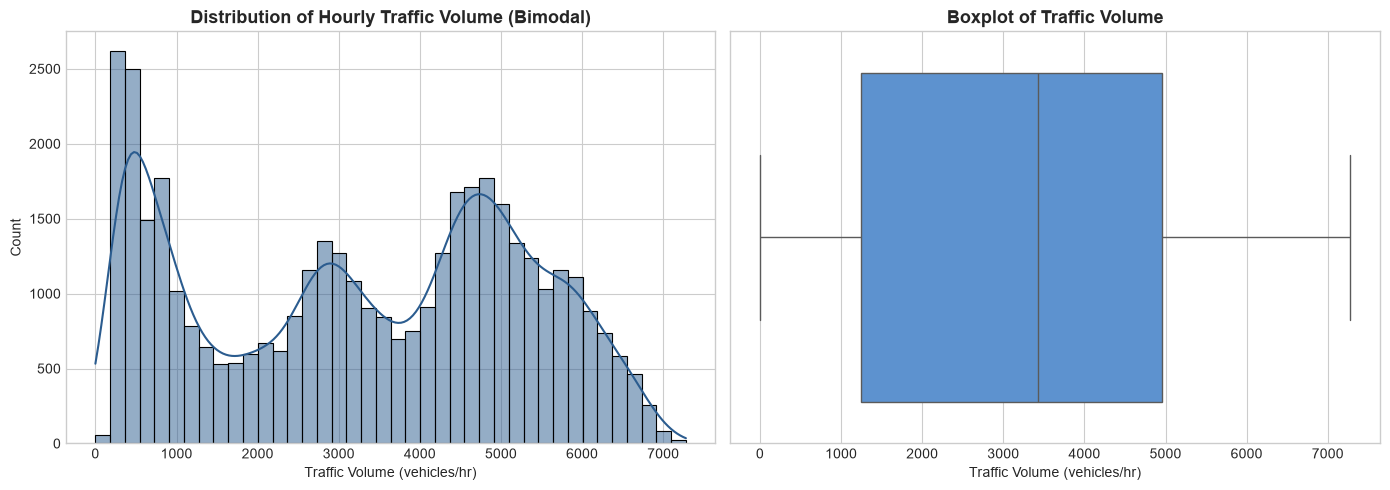

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['traffic_volume'], kde=True, ax=axes[0], color='#2b5c8f', bins=40)
axes[0].set_title("Distribution of Hourly Traffic Volume (Bimodal)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Traffic Volume (vehicles/hr)")

sns.boxplot(x=df['traffic_volume'], ax=axes[1], color='#4a90e2')
axes[1].set_title("Boxplot of Traffic Volume", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Traffic Volume (vehicles/hr)")

plt.tight_layout()
plt.show()

## 4. Hourly Diurnal Patterns & Rush Hours

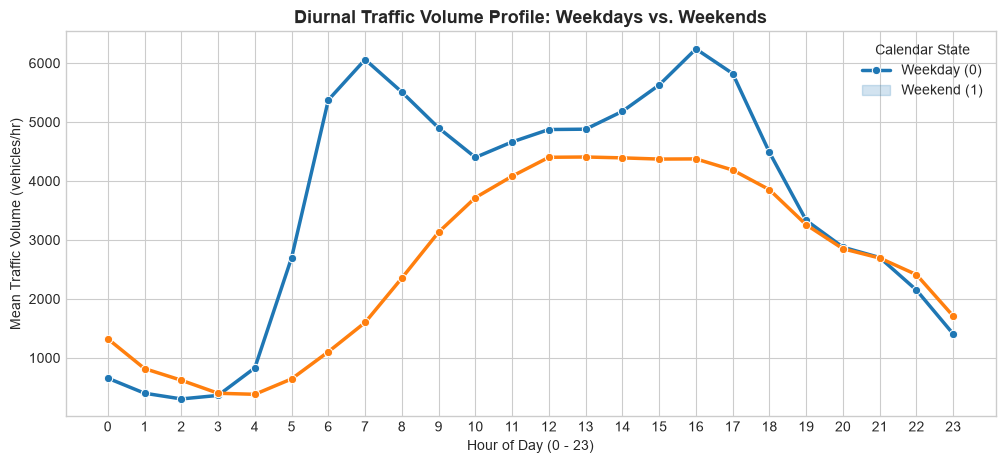

In [3]:
plt.figure(figsize=(12, 5))
hourly_avg = df.groupby(['hour', 'is_weekend'])['traffic_volume'].mean().reset_index()
sns.lineplot(data=hourly_avg, x='hour', y='traffic_volume', hue='is_weekend', marker='o', palette=['#1f77b4', '#ff7f0e'], linewidth=2.5)
plt.title("Diurnal Traffic Volume Profile: Weekdays vs. Weekends", fontsize=13, fontweight='bold')
plt.xlabel("Hour of Day (0 - 23)")
plt.ylabel("Mean Traffic Volume (vehicles/hr)")
plt.xticks(range(0, 24))
plt.legend(["Weekday (0)", "Weekend (1)"], title="Calendar State")
plt.show()

## 5. Day of Week & Weekly Profile

C:\Users\bhoga\AppData\Local\Temp\ipykernel_23280\4255679812.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_traffic, x='day_name', y='traffic_volume', palette='Blues_d', edgecolor='black')


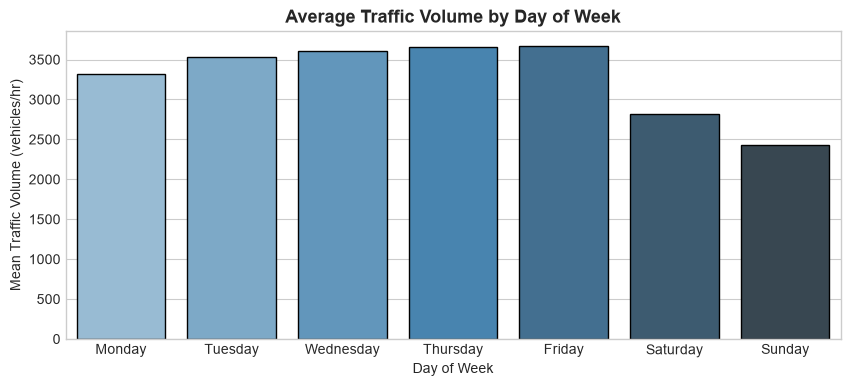

In [4]:
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_traffic = df.groupby('day_of_week')['traffic_volume'].mean().reset_index()
daily_traffic['day_name'] = daily_traffic['day_of_week'].map(lambda x: day_names[x])

plt.figure(figsize=(10, 4))
sns.barplot(data=daily_traffic, x='day_name', y='traffic_volume', palette='Blues_d', edgecolor='black')
plt.title("Average Traffic Volume by Day of Week", fontsize=13, fontweight='bold')
plt.xlabel("Day of Week")
plt.ylabel("Mean Traffic Volume (vehicles/hr)")
plt.show()

## 6. Weather Category Impact

C:\Users\bhoga\AppData\Local\Temp\ipykernel_23280\71878455.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='weather_main', y='traffic_volume', order=weather_order, palette='viridis')


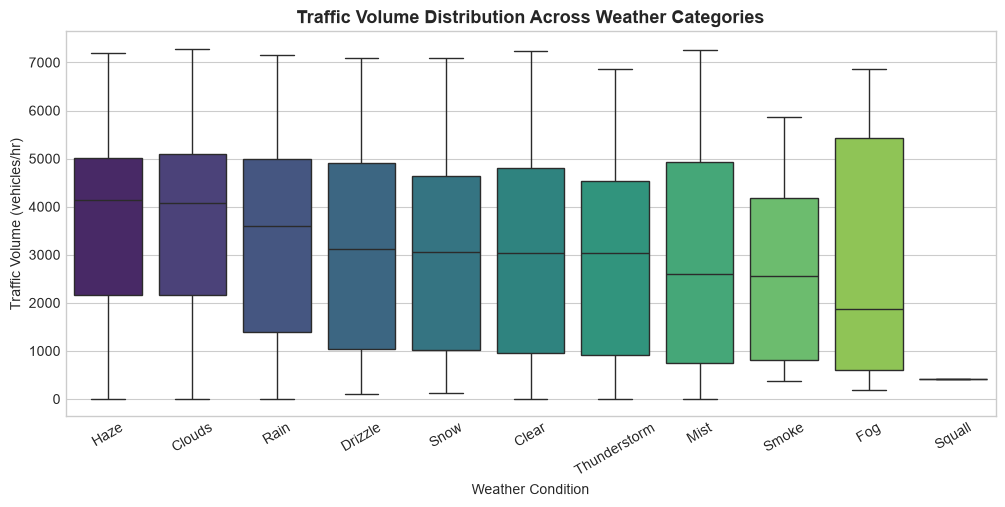

In [5]:
plt.figure(figsize=(12, 5))
weather_order = df.groupby('weather_main')['traffic_volume'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='weather_main', y='traffic_volume', order=weather_order, palette='viridis')
plt.title("Traffic Volume Distribution Across Weather Categories", fontsize=13, fontweight='bold')
plt.xlabel("Weather Condition")
plt.ylabel("Traffic Volume (vehicles/hr)")
plt.xticks(rotation=30)
plt.show()

## 7. Numerical Feature Correlation Matrix

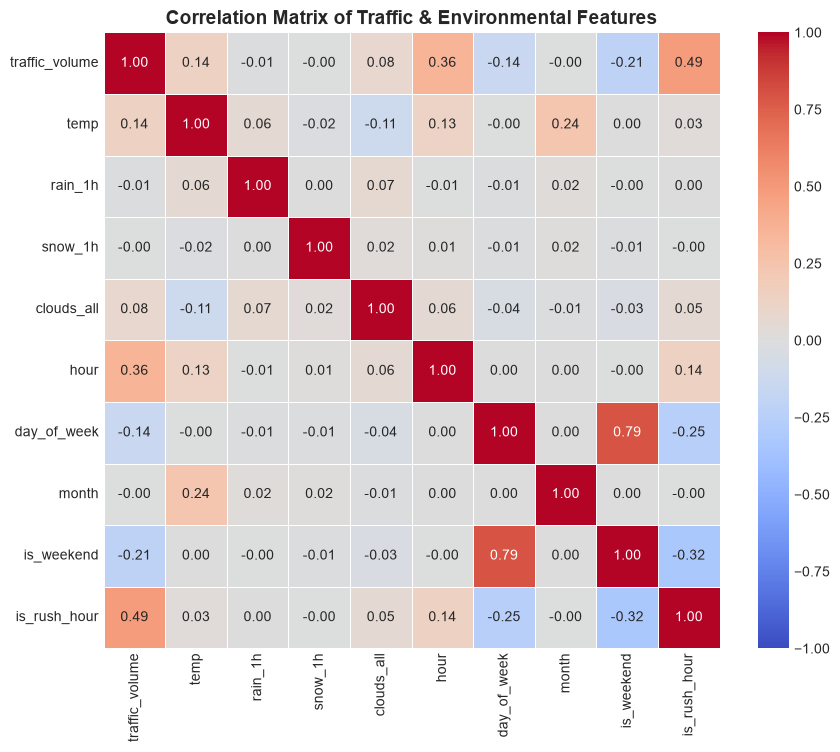

In [6]:
num_cols = ['traffic_volume', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour']
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Matrix of Traffic & Environmental Features", fontsize=14, fontweight='bold')
plt.show()

## 8. Summary of EDA Findings
- **Temporal Dominance:** The feature `hour` exhibits the highest linear correlation with `traffic_volume` ($r \approx 0.35$), with twin peaks corresponding to morning rush ($7-9\text{ AM}$) and evening rush ($16-19\text{ PM}$).
- **Weekend Disparity:** Weekends show a unimodal mid-day leisure traffic distribution with lower total capacity.
- **Weather Sensitivity:** Inclement weather conditions (squall, snow, fog) increase variance and lower average velocities.